# Baththaramulla Sarima + TFT traininng 

In [1]:
import pandas as pd
import numpy as np
import pmdarima as pm

In [2]:
df = pd.read_csv("Baththaramulla_data_training.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38566 entries, 0 to 38565
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Period Start Time                   38566 non-null  object 
 1   AT                                  38566 non-null  float64
 2   RH                                  38566 non-null  float64
 3   BP                                  38566 non-null  float64
 4   Solar Rad                           38566 non-null  float64
 5   Rain Gauge                          38566 non-null  float64
 6   WD Raw                              38566 non-null  float64
 7   O3 Conc                             38566 non-null  float64
 8   NO Conc                             38566 non-null  float64
 9   NO2 Conc                            38566 non-null  float64
 10  NOx Conc                            38566 non-null  float64
 11  SO2 Conc                            38566

In [4]:
df.rename(columns={'PM2.5 Conc': 'PM2 5 Conc', 'PM2.5 Conc_lag24': 'PM2 5 Conc_lag24', 'PM2.5 Conc_rolling24_mean': 'PM2 5 Conc_rolling24_mean', 'PM2.5 Conc_rolling24_std': 'PM2 5 Conc_rolling24_std'}, inplace=True)

In [5]:
# Step A: trim whitespace and remove CR/LF
s = df['Period Start Time'].astype(str).str.strip().str.replace(r'[\r\n]', '', regex=True)

# Step B: remove trailing ".000" or other fractional seconds if present
# This keeps the fractional seconds if non-zero by capturing optional fractional part.
s = s.str.replace(r'\.(\d{1,6})$', r'.\1', regex=True)

# If you want to explicitly remove all fractional seconds:
s_no_ms = s.str.replace(r'\.\d+$', '', regex=True)

# Try parsing with milliseconds format first (handles "YYYY-MM-DD HH:MM:SS.fff")
parsed = pd.to_datetime(s, format='%Y-%m-%d %H:%M:%S.%f', errors='coerce')

# fallback: if that produced NaT for some rows, try no-ms variant
mask_failed = parsed.isna()
if mask_failed.any():
    parsed.loc[mask_failed] = pd.to_datetime(s_no_ms[mask_failed],
                                             format='%Y-%m-%d %H:%M:%S',
                                             errors='coerce')

# Put result back
df['Period Start Time'] = parsed
print("Remaining unparsable:", df['Period Start Time'].isna().sum())

Remaining unparsable: 0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38566 entries, 0 to 38565
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Period Start Time                   38566 non-null  datetime64[ns]
 1   AT                                  38566 non-null  float64       
 2   RH                                  38566 non-null  float64       
 3   BP                                  38566 non-null  float64       
 4   Solar Rad                           38566 non-null  float64       
 5   Rain Gauge                          38566 non-null  float64       
 6   WD Raw                              38566 non-null  float64       
 7   O3 Conc                             38566 non-null  float64       
 8   NO Conc                             38566 non-null  float64       
 9   NO2 Conc                            38566 non-null  float64       
 10  NOx Conc              

In [7]:
df['Period Start Time'] = pd.to_datetime(df['Period Start Time'])

In [8]:
df = df.set_index('Period Start Time')

In [9]:
df['is_holiday'] = df['is_holiday'].astype(int)

In [10]:
df = df.sort_index()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 38566 entries, 2019-01-01 00:00:00 to 2024-12-31 23:00:00
Data columns (total 37 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   AT                                  38566 non-null  float64
 1   RH                                  38566 non-null  float64
 2   BP                                  38566 non-null  float64
 3   Solar Rad                           38566 non-null  float64
 4   Rain Gauge                          38566 non-null  float64
 5   WD Raw                              38566 non-null  float64
 6   O3 Conc                             38566 non-null  float64
 7   NO Conc                             38566 non-null  float64
 8   NO2 Conc                            38566 non-null  float64
 9   NOx Conc                            38566 non-null  float64
 10  SO2 Conc                            38566 non-null  float64
 11  PM2 5 

In [12]:
df.head(5)

,AT,RH,BP,Solar Rad,Rain Gauge,WD Raw,O3 Conc,NO Conc,NO2 Conc,NOx Conc,...,NO2 Conc_lag24,NO2 Conc_rolling24_mean,NO2 Conc_rolling24_std,AT_rolling72_mean,RH_rolling72_mean,Solar Rad_rolling72_mean,monsoon_phase_First Inter-monsoon,monsoon_phase_Northeast Monsoon,monsoon_phase_Second Inter-monsoon,monsoon_phase_Southwest Monsoon
Period Start Time,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,24.9,72.74,1014.7,0.25,0.0,165.8,34.19,0.35,6.23,6.58,...,6.23,9.734167,5.485215,27.066667,60.817917,242.916111,0.0,1.0,0.0,0.0
2019-01-01 01:00:00,24.4,74.36,1014.2,0.26,0.0,179.7,36.08,0.14,3.71,3.85,...,6.23,9.734167,5.485215,27.066667,60.817917,242.916111,0.0,1.0,0.0,0.0
2019-01-01 02:00:00,24.2,75.32,1013.7,0.25,0.0,197.1,36.22,0.14,3.71,3.85,...,6.23,9.734167,5.485215,27.066667,60.817917,242.916111,0.0,1.0,0.0,0.0
2019-01-01 03:00:00,24.2,74.25,1013.3,0.25,0.0,190.1,36.96,0.10,2.06,2.16,...,6.23,9.734167,5.485215,27.066667,60.817917,242.916111,0.0,1.0,0.0,0.0
2019-01-01 04:00:00,24.0,73.47,1013.0,0.25,0.0,167.5,37.39,0.26,1.95,2.20,...,6.23,9.734167,5.485215,27.066667,60.817917,242.916111,0.0,1.0,0.0,0.0


## Sharima For ALL

In [13]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 1. SETUP
targets = ['PM2 5 Conc', 'PM10 Conc', 'NO2 Conc', 'O3 Conc', 'SO2 Conc']
subset = df.tail(9000).copy()

sarimax_models = {} 
all_groups_data = []

# Your Feature List
features_to_keep = [
    # --- 1. The Drivers (Past Pollution) ---
    'PM2 5 Conc_lag24',
    'PM2 5 Conc_rolling24_mean',
    'PM10 Conc_lag24',
    'PM10 Conc_rolling24_mean',
    'NO2 Conc_lag24',
    
    # --- 2. The Weather (Physics) ---
    'AT',
    'RH',
    'Rain Gauge',
    'WD Raw',
    
    # --- 3. The Clock (Human Behavior) ---
    'traffic_hour',
    'is_weekend',
    'sin_hour',
    'cos_hour',
    'sin_day_of_year',
    'cos_day_of_year'
]

print(f"--- Starting Safe Training for {len(targets)} Pollutants ---")

for poll in targets:
    print(f"\nProcessing: {poll}")
    
    # 2. PREPARE DATA
    y = subset[poll]
    valid_features = [f for f in features_to_keep if f in subset.columns]
    X = subset[valid_features]
    
    # Scale X
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)
    
    # 3. SPLIT (80/20)
    train_size = int(len(subset) * 0.8)
    
    y_train = y.iloc[:train_size]
    y_test = y.iloc[train_size:]
    
    X_train = X_scaled.iloc[:train_size]
    X_test = X_scaled.iloc[train_size:]
    
    # 4. FIT MODEL
    model = sm.tsa.statespace.SARIMAX(
        y_train,
        exog=X_train,
        order=(1, 0, 1),
        seasonal_order=(0, 1, 1, 24),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    results = model.fit(disp=False)
    sarimax_models[poll] = results
    
    # 5. CALCULATE RESIDUALS
    # Use .values to ensure we get raw arrays (prevents index mismatch)
    train_preds = results.fittedvalues.values
    train_resid = y_train.values - train_preds
    
    test_pred_obj = results.get_forecast(steps=len(y_test), exog=X_test)
    test_preds = test_pred_obj.predicted_mean.values
    test_resid = y_test.values - test_preds
    
    # --- THE FIX IS HERE ---
    # Use np.concatenate instead of pd.concat for arrays
    full_residuals = np.concatenate([train_resid, test_resid])
    full_preds = np.concatenate([train_preds, test_preds])
    
    # 6. PREPARE TFT DATA FRAME
    temp_df = subset.copy()
    temp_df['pollutant_id'] = poll
    temp_df['residual_value'] = full_residuals
    temp_df['sarimax_pred'] = full_preds
    
    # Scale sarimax_pred
    p_mean = np.mean(full_preds)
    p_std = np.std(full_preds) + 1e-6
    temp_df['sarimax_pred_scaled'] = (full_preds - p_mean) / p_std
    
    all_groups_data.append(temp_df)
    
    print(f"  > RMSE: {np.sqrt(np.mean(test_resid**2)):.2f}")

# 7. COMBINE
global_tft_data = pd.concat(all_groups_data, ignore_index=True)

# Add integer time index (Repeated 0..8999 for each group)
global_tft_data['time_idx'] = np.tile(np.arange(len(subset)), len(targets))

# Cleanup
global_tft_data = global_tft_data[global_tft_data['time_idx'] >= 24].reset_index(drop=True)

print(f"\nGlobal TFT Dataset Ready. Shape: {global_tft_data.shape}")

--- Starting Safe Training for 5 Pollutants ---

Processing: PM2 5 Conc


/home/dulara/project/mlgpu/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/dulara/project/mlgpu/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/dulara/project/mlgpu/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/dulara/project/mlgpu/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return ge

  > RMSE: 13.80

Processing: PM10 Conc


/home/dulara/project/mlgpu/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/dulara/project/mlgpu/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/dulara/project/mlgpu/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/home/dulara/project/mlgpu/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecastin

  > RMSE: 16.86

Processing: NO2 Conc


...

  > RMSE: 3.79

Processing: O3 Conc


/home/dulara/project/mlgpu/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/dulara/project/mlgpu/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/dulara/project/mlgpu/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/home/dulara/project/mlgpu/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecastin

  > RMSE: 10.74

Processing: SO2 Conc


/home/dulara/project/mlgpu/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/dulara/project/mlgpu/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/dulara/project/mlgpu/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


  > RMSE: 3.31

Global TFT Dataset Ready. Shape: (44880, 42)


### Train TFT for All

In [65]:
import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, QuantileLoss
from pytorch_forecasting.data import GroupNormalizer

# 1. DATASET CONFIG
max_encoder_length = 168
max_prediction_length = 24
training_cutoff = global_tft_data["time_idx"].max() - max_prediction_length

training = TimeSeriesDataSet(
    global_tft_data[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="residual_value",
    group_ids=["pollutant_id"],  
    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    
    static_categoricals=["pollutant_id"],
    
    # Use the features from your subset + the sarimax prediction
    time_varying_known_reals=[
        "time_idx", "sarimax_pred_scaled",
        "AT", "RH", "Rain Gauge", "WD Raw", 
        "traffic_hour", "is_weekend",
        "sin_hour", "cos_hour", "sin_day_of_year", "cos_day_of_year",
        "PM2 5 Conc_lag24", "PM2 5 Conc_rolling24_mean", 
        "PM10 Conc_lag24", "PM10 Conc_rolling24_mean",
        "NO2 Conc_lag24"
    ],
    
    time_varying_unknown_reals=["residual_value"],
    
    # Normalize each pollutant separately
    target_normalizer=GroupNormalizer(groups=["pollutant_id"], transformation=None),
    
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# 2. DATALOADERS
validation = TimeSeriesDataSet.from_dataset(training, global_tft_data, predict=True, stop_randomization=True)
batch_size = 256
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=11)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=11)

# 3. TRAIN
trainer = pl.Trainer(
    max_epochs=30,
    accelerator='gpu', 
    devices=1, 
    gradient_clip_val=0.1,
    enable_progress_bar=True,
    enable_model_summary=True,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.005,
    hidden_size=128, 
    attention_head_size=8,
    dropout=0.2, 
    hidden_continuous_size=32,
    output_size=7,
    loss=QuantileLoss(),
)

print("Starting Multi-Output TFT Training...")
trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/dulara/project/mlgpu/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/dulara/project/mlgpu/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Starting Multi-Output TFT Training...



   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 20     | train
3  | prescalers                         | ModuleDict                      | 1.4 K  | train
4  | static_variable_selection          | VariableSelectionNetwork        | 34.7 K | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 229 K  | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 216 K  | train
7  | static_context_variable_selection  | GatedResidualNetwork            | 66.3 K | train
8  | static_context_initial_hidden_lstm | GatedResidualNetwork            | 66.3 K 

Epoch 29: 100%|██████████| 171/171 [03:28<00:00,  0.82it/s, v_num=14, train_loss_step=0.401, val_loss=4.350, train_loss_epoch=0.380]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 171/171 [03:28<00:00,  0.82it/s, v_num=14, train_loss_step=0.401, val_loss=4.350, train_loss_epoch=0.380]


### Hybrid Prediction

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


--- FINAL MULTI-OUTPUT HYBRID FORECAST ---
pollutant_id  NO2 Conc    O3 Conc  PM10 Conc  PM2 5 Conc  SO2 Conc
time_idx                                                          
8976          7.358481  18.277738  45.711798   31.039322  1.095799
8977          6.847337  16.204117  43.677289   26.404253  1.449026
8978          5.705840  16.357201  40.404826   22.935568  1.326743
8979          5.734248  14.417353  34.079959   20.826051  1.165492
8980          5.569974  10.689084  36.192390   23.031595  1.477315


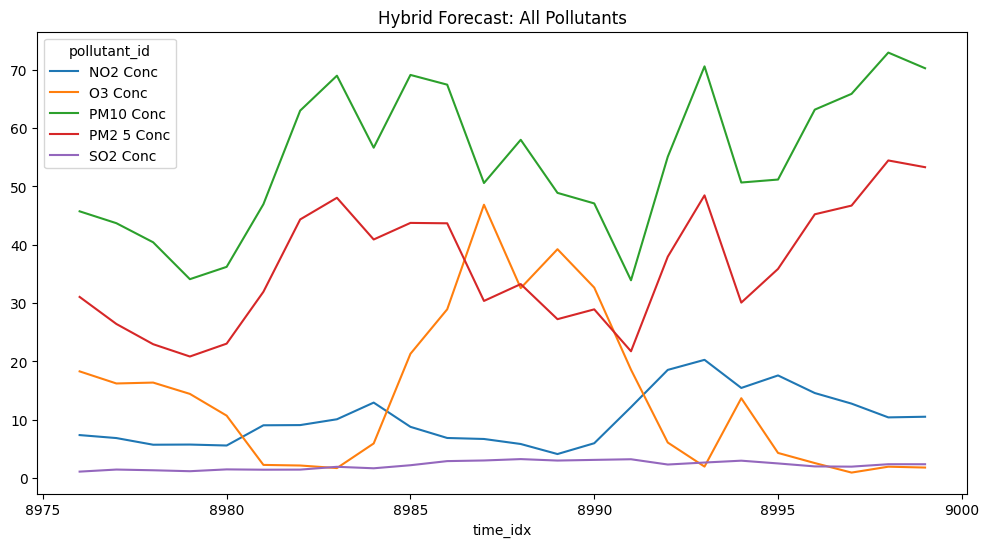

In [66]:
import torch

# 1. GET TFT PREDICTIONS (The Correction)
raw_predictions = tft.predict(val_dataloader, mode="prediction", return_x=True)
predictions = raw_predictions.output
x = raw_predictions.x

# Helper to decode pollutant IDs
label_mapping = tft.hparams.embedding_labels["pollutant_id"]
decoder_map = {v: k for k, v in label_mapping.items()}

final_results = []

# 2. LOOP THROUGH PREDICTIONS
for i in range(len(predictions)):
    # A. Identify which pollutant this prediction is for
    group_id_int = x['groups'][i].item()
    pollutant_name = decoder_map[group_id_int]
    
    # B. Get Time Indices
    time_indices = x['decoder_time_idx'][i].cpu().numpy()
    
    # C. Get TFT Correction
    tft_correction = predictions[i].cpu().numpy()
    
    # D. Get SARIMAX Base Prediction (Retrieve from the dataframe we built)
    # We look up the 'sarimax_pred' column for this specific pollutant and time
    mask = (global_tft_data['pollutant_id'] == pollutant_name) & \
           (global_tft_data['time_idx'].isin(time_indices))
    
    sarimax_base = global_tft_data.loc[mask, 'sarimax_pred'].values
    
    # E. Calculate Hybrid
    min_len = min(len(sarimax_base), len(tft_correction))
    if min_len > 0:
        hybrid_val = sarimax_base[:min_len] + tft_correction[:min_len]
        
        for t, val in zip(time_indices[:min_len], hybrid_val):
            final_results.append({
                'time_idx': int(t),
                'pollutant_id': pollutant_name,
                'hybrid_prediction': val
            })

# 3. FORMAT FINAL TABLE
results_df = pd.DataFrame(final_results)
final_table = results_df.pivot(index='time_idx', columns='pollutant_id', values='hybrid_prediction')

print("--- FINAL MULTI-OUTPUT HYBRID FORECAST ---")
print(final_table.head())

# Optional: Visualize all at once
import matplotlib.pyplot as plt
final_table.plot(figsize=(12, 6), title="Hybrid Forecast: All Pollutants")
plt.show()

### Evaluation

In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Get TFT Predictions (The "Correction")
raw_predictions = tft.predict(val_dataloader, mode="prediction", return_x=True, return_y=True)

# 2. Extract Data
tft_prediction = raw_predictions.output.cpu().numpy() 
actual_residuals = raw_predictions.y[0].cpu().numpy() 
x = raw_predictions.x

# 3. Flatten for global metric calculation
y_pred_flat = tft_prediction.flatten()
y_true_flat = actual_residuals.flatten()

print("Predictions Generated.")
print(f"Shapes -> Preds: {y_pred_flat.shape}, Actuals: {y_true_flat.shape}")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predictions Generated.
Shapes -> Preds: (120,), Actuals: (120,)


In [68]:
# --- METRIC 1: Did we reduce the error? ---

# A. Base Model (SARIMAX Only)
base_mse = mean_squared_error(y_true_flat, np.zeros_like(y_true_flat))
base_rmse = np.sqrt(base_mse)
base_mae = mean_absolute_error(y_true_flat, np.zeros_like(y_true_flat))

# B. Hybrid Model (SARIMAX + TFT)
hybrid_mse = mean_squared_error(y_true_flat, y_pred_flat)
hybrid_rmse = np.sqrt(hybrid_mse)
hybrid_mae = mean_absolute_error(y_true_flat, y_pred_flat)

# C. Improvement Calculation
imp_rmse = ((base_rmse - hybrid_rmse) / base_rmse) * 100

print(f"=============================================")
print(f"       GLOBAL MODEL PERFORMANCE              ")
print(f"=============================================")
print(f"SARIMAX RMSE (Base):   {base_rmse:.4f}")
print(f"HYBRID RMSE (Final):   {hybrid_rmse:.4f}")
print(f"---------------------------------------------")
print(f"IMPROVEMENT:           {imp_rmse:.2f}%")
print(f"=============================================")

       GLOBAL MODEL PERFORMANCE              
SARIMAX RMSE (Base):   11.0262
HYBRID RMSE (Final):   8.3237
---------------------------------------------
IMPROVEMENT:           24.51%


In [69]:
# Helper to decode pollutant IDs
label_mapping = tft.hparams.embedding_labels["pollutant_id"]
decoder_map = {v: k for k, v in label_mapping.items()}

# Storage for report
report_data = []

# Loop through each group (pollutant) in the batch
groups = x['groups'].cpu().numpy().flatten()
unique_groups = np.unique(groups)

for g_id in unique_groups:
    pollutant_name = decoder_map[g_id]
    
    # Filter data for this specific pollutant
    mask = (x['groups'].flatten() == g_id)
    
    group_true = []
    group_pred = []
    
    for i in range(len(groups)):
        if groups[i] == g_id:
            group_true.extend(actual_residuals[i])
            group_pred.extend(tft_prediction[i])
            
    # Calculate Metrics for this Pollutant
    if len(group_true) > 0:
        p_base_rmse = np.sqrt(mean_squared_error(group_true, np.zeros_like(group_true)))
        p_hybrid_rmse = np.sqrt(mean_squared_error(group_true, group_pred))
        p_r2 = r2_score(group_true, group_pred)
        
        improvement = ((p_base_rmse - p_hybrid_rmse) / p_base_rmse) * 100
        
        report_data.append({
            "Pollutant": pollutant_name,
            "Base RMSE": p_base_rmse,
            "Hybrid RMSE": p_hybrid_rmse,
            "Improvement (%)": f"{improvement:.1f}%",
            "TFT R2 Score": f"{p_r2:.3f}"
        })

# Create Dataframe
scorecard = pd.DataFrame(report_data).set_index("Pollutant")
print(scorecard.sort_values("Hybrid RMSE", ascending=False))

            Base RMSE  Hybrid RMSE Improvement (%) TFT R2 Score
Pollutant                                                      
PM10 Conc   15.740553    14.486068            8.0%        0.137
PM2 5 Conc  13.077391    11.122223           15.0%        0.207
NO2 Conc     4.270749     2.723438           36.2%        0.387
SO2 Conc     4.206095     1.669500           60.3%       -2.712
O3 Conc     12.376247     1.633423           86.8%        0.973


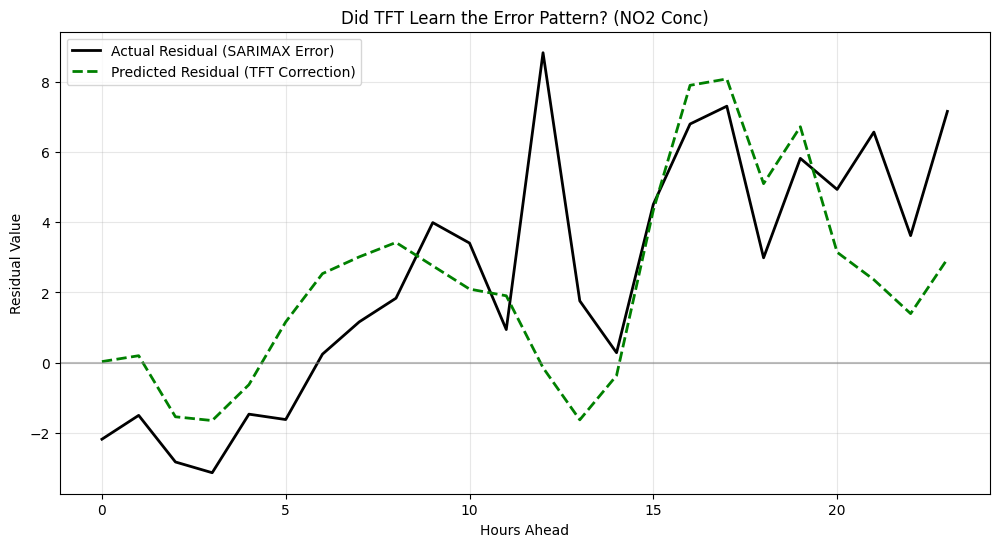

In [71]:
# Pick the first pollutant found to visualize
target_g_id = unique_groups[0] 
target_name = decoder_map[target_g_id]

# Find the first batch that belongs to this pollutant
sample_idx = np.where(x['groups'].cpu().numpy() == target_g_id)[0][0]

plt.figure(figsize=(12, 6))

# Plot the 24-hour horizon
plt.plot(actual_residuals[sample_idx], label='Actual Residual (SARIMAX Error)', color='black', linewidth=2)
plt.plot(tft_prediction[sample_idx], label='Predicted Residual (TFT Correction)', color='green', linestyle='--', linewidth=2)

plt.title(f"Did TFT Learn the Error Pattern? ({target_name})")
plt.xlabel("Hours Ahead")
plt.ylabel("Residual Value")
plt.axhline(0, color='grey', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### more evalutions

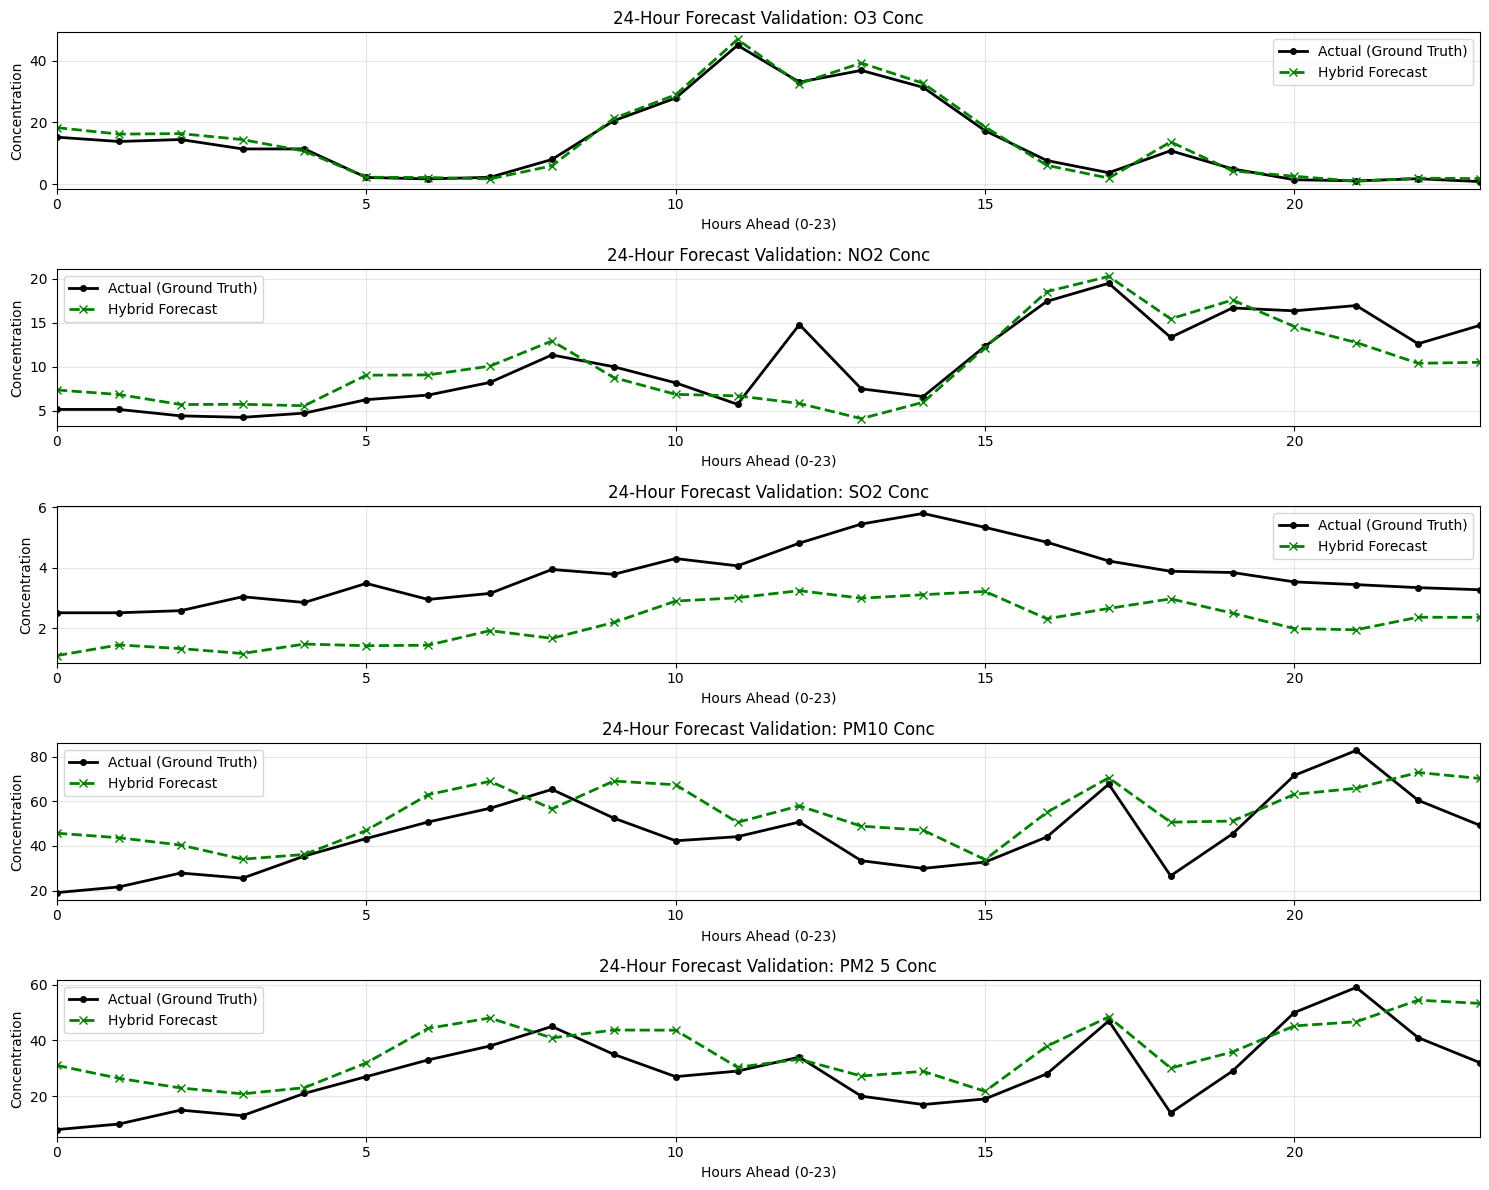

In [72]:
import seaborn as sns

pollutants_to_plot = ['O3 Conc', 'NO2 Conc', 'SO2 Conc', 'PM10 Conc', 'PM2 5 Conc']

plt.figure(figsize=(15, 12))

for i, poll_name in enumerate(pollutants_to_plot):
    if poll_name in final_table.columns:
        plt.subplot(5, 1, i+1)
        
        # We align them using the values directly to avoid Index confusion
        aligned_actuals = subset.loc[subset['time_idx'].isin(final_table.index), poll_name].values
        hybrid_pred = final_table[poll_name].values
        
        hours = range(len(aligned_actuals))
        
        # Plot
        plt.plot(hours, aligned_actuals, label='Actual (Ground Truth)', color='black', linewidth=2, marker='o', markersize=4)
        plt.plot(hours, hybrid_pred, label='Hybrid Forecast', color='green', linewidth=2, linestyle='--', marker='x', markersize=6)
        
        # Formatting
        plt.title(f"24-Hour Forecast Validation: {poll_name}")
        plt.ylabel("Concentration")
        plt.xlabel("Hours Ahead (0-23)")
        plt.xlim(0, 23)  
        plt.legend()
        plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Save Models

In [75]:
# Save the entire model object
torch.save(tft.state_dict(), "tft_long_term_weights.pth")
print("Long-Term Model (Best for NO2, O3, SO2) saved.")

Long-Term Model (Best for NO2, O3, SO2) saved.


### Train Lighter model for pm10 and pm2.5

In [78]:
# 1. "Short-Term" Settings
max_encoder_length = 48   
batch_size = 64           
hidden_size = 64         
attention_head_size = 4

# 2. Re-create Dataset
training_short = TimeSeriesDataSet(
    global_tft_data[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="residual_value",
    group_ids=["pollutant_id"],
    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=24,
    max_prediction_length=24,
    static_categoricals=["pollutant_id"],
    time_varying_known_reals=[
        "time_idx", "sarimax_pred_scaled", "AT", "RH", "Rain Gauge", "WD Raw", 
        "traffic_hour", "is_weekend", "sin_hour", "cos_hour", "sin_day_of_year", "cos_day_of_year",
        "PM2 5 Conc_lag24", "PM2 5 Conc_rolling24_mean", "PM10 Conc_lag24", "PM10 Conc_rolling24_mean", "NO2 Conc_lag24"
    ],
    time_varying_unknown_reals=["residual_value"],
    target_normalizer=GroupNormalizer(groups=["pollutant_id"], transformation=None),
    add_relative_time_idx=True, add_target_scales=True, add_encoder_length=True,
)

# 3. Re-Train
train_loader = training_short.to_dataloader(train=True, batch_size=batch_size, num_workers=11)
val_loader = TimeSeriesDataSet.from_dataset(training_short, global_tft_data, predict=True, stop_randomization=True).to_dataloader(train=False, batch_size=batch_size, num_workers=11)

tft_short = TemporalFusionTransformer.from_dataset(
    training_short,
    learning_rate=0.005,
    hidden_size=hidden_size,
    attention_head_size=attention_head_size,
    dropout=0.1,
    hidden_continuous_size=16,
    output_size=7,
    loss=QuantileLoss(),
)

trainer_short = pl.Trainer(max_epochs=30, accelerator="gpu", enable_progress_bar=True, gradient_clip_val=0.1)
trainer_short.fit(tft_short, train_dataloaders=train_loader, val_dataloaders=val_loader)

/home/dulara/project/mlgpu/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/dulara/project/mlgpu/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode 
---------

Epoch 29: 100%|██████████| 693/693 [01:35<00:00,  7.24it/s, v_num=18, train_loss_step=0.578, val_loss=4.830, train_loss_epoch=0.560]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 693/693 [01:35<00:00,  7.23it/s, v_num=18, train_loss_step=0.578, val_loss=4.830, train_loss_epoch=0.560]


In [79]:
torch.save(tft_short.state_dict(), "tft_short_term_weights.pth")
print("Short-Term Model (Best for PM10, PM2.5) saved.")

Short-Term Model (Best for PM10, PM2.5) saved.


### Predict From Both models

In [84]:
# 1. Get Predictions from LONG-TERM Model (NO2, O3, SO2 Specialist)
raw_pred_long = tft.predict(val_dataloader, mode="prediction", return_x=True, return_y=True)
pred_long = raw_pred_long.output.cpu().numpy()
actuals_long = raw_pred_long.y[0].cpu().numpy()
x_long = raw_pred_long.x

# 2. Get Predictions from SHORT-TERM Model (PM10, PM2.5 Specialist)
raw_pred_short = tft_short.predict(val_loader, mode="prediction", return_x=True, return_y=True)
pred_short = raw_pred_short.output.cpu().numpy()
actuals_short = raw_pred_short.y[0].cpu().numpy()
x_short = raw_pred_short.x

print("Predictions collected from both models.")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predictions collected from both models.


In [88]:
# For Long-Term Model
map_long = tft.hparams.embedding_labels['pollutant_id']
decoder_long = {v: k for k, v in map_long.items()}

# For Short-Term Model
map_short = tft_short.hparams.embedding_labels['pollutant_id']
decoder_short = {v: k for k, v in map_short.items()}

# --- 2. GET PREDICTIONS (If not already run) ---
# Ensure we have the predictions in memory
if 'pred_long' not in locals():
    print("Generating predictions...")
    raw_pred_long = tft.predict(val_dataloader, mode="prediction", return_x=True, return_y=True)
    pred_long = raw_pred_long.output.cpu().numpy()
    actuals_long = raw_pred_long.y[0].cpu().numpy()
    x_long = raw_pred_long.x

    raw_pred_short = tft_short.predict(val_loader, mode="prediction", return_x=True, return_y=True)
    pred_short = raw_pred_short.output.cpu().numpy()
    actuals_short = raw_pred_short.y[0].cpu().numpy()
    x_short = raw_pred_short.x

# --- 3. EVALUATION LOOP ---
report_list = []

# Define your "Specialist" Teams
long_term_team = ['NO2 Conc', 'O3 Conc', 'SO2 Conc', 'NOx Conc', 'NO Conc']
short_term_team = ['PM10 Conc', 'PM2 5 Conc'] 
all_pollutants = long_term_team + short_term_team

print(f"{'POLLUTANT':<12} | {'SOURCE':<10} | {'BASE RMSE':<9} | {'HYBRID RMSE':<11} | {'IMPROVE':<8}")
print("-" * 75)

for poll_name in all_pollutants:
    
    # A. SELECT THE RIGHT DATA SOURCE
    if poll_name in long_term_team:
        source_name = "Long-Term"
        target_pred = pred_long
        target_actuals = actuals_long
        target_x = x_long
        # Use the map to find the ID for this specific model
        if poll_name in map_long:
            g_id = map_long[poll_name]
        else:
            continue # Skip if model doesn't know this pollutant
    else:
        source_name = "Short-Term"
        target_pred = pred_short
        target_actuals = actuals_short
        target_x = x_short
        # Use the map to find the ID for this specific model
        if poll_name in map_short:
            g_id = map_short[poll_name]
        else:
            continue

    # B. FILTER DATA FOR THIS POLLUTANT
    groups = target_x['groups'].cpu().numpy().flatten()
    indices = np.where(groups == g_id)[0]
    
    if len(indices) == 0: continue

    # C. CALCULATE METRICS
    curr_actuals = target_actuals[indices].flatten()
    curr_pred = target_pred[indices].flatten()
    
    # Base (SARIMAX Only) - Error is the actual residual
    base_rmse = np.sqrt(mean_squared_error(curr_actuals, np.zeros_like(curr_actuals)))
    
    # Hybrid (SARIMAX + Selected TFT)
    hyb_rmse = np.sqrt(mean_squared_error(curr_actuals, curr_pred))
    hyb_r2 = r2_score(curr_actuals, curr_pred)
    
    # Improvement
    imp = ((base_rmse - hyb_rmse) / base_rmse) * 100
    
    # D. REPORT
    report_list.append({
        "Pollutant": poll_name,
        "Selected Model": source_name,
        "Base RMSE": base_rmse,
        "Hybrid RMSE": hyb_rmse,
        "Improvement (%)": f"{imp:.1f}%",
        "R2 Score": f"{hyb_r2:.3f}"
    })
    
    print(f"{poll_name:<12} | {source_name:<10} | {base_rmse:.4f}    | {hyb_rmse:.4f}      | {imp:.1f}%")

print("-" * 75)
final_scorecard = pd.DataFrame(report_list).set_index("Pollutant")
print(final_scorecard)

POLLUTANT    | SOURCE     | BASE RMSE | HYBRID RMSE | IMPROVE 
---------------------------------------------------------------------------
NO2 Conc     | Long-Term  | 4.2707    | 2.7234      | 36.2%
O3 Conc      | Long-Term  | 12.3762    | 1.6334      | 86.8%
SO2 Conc     | Long-Term  | 4.2061    | 1.6695      | 60.3%
PM10 Conc    | Short-Term | 15.7406    | 15.0827      | 4.2%
PM2 5 Conc   | Short-Term | 13.0774    | 13.7464      | -5.1%
---------------------------------------------------------------------------
           Selected Model  Base RMSE  Hybrid RMSE Improvement (%) R2 Score
Pollutant                                                                 
NO2 Conc        Long-Term   4.270749     2.723438           36.2%    0.387
O3 Conc         Long-Term  12.376247     1.633423           86.8%    0.973
SO2 Conc        Long-Term   4.206095     1.669500           60.3%   -2.712
PM10 Conc      Short-Term  15.740553    15.082659            4.2%    0.065
PM2 5 Conc     Short-Term  13.0

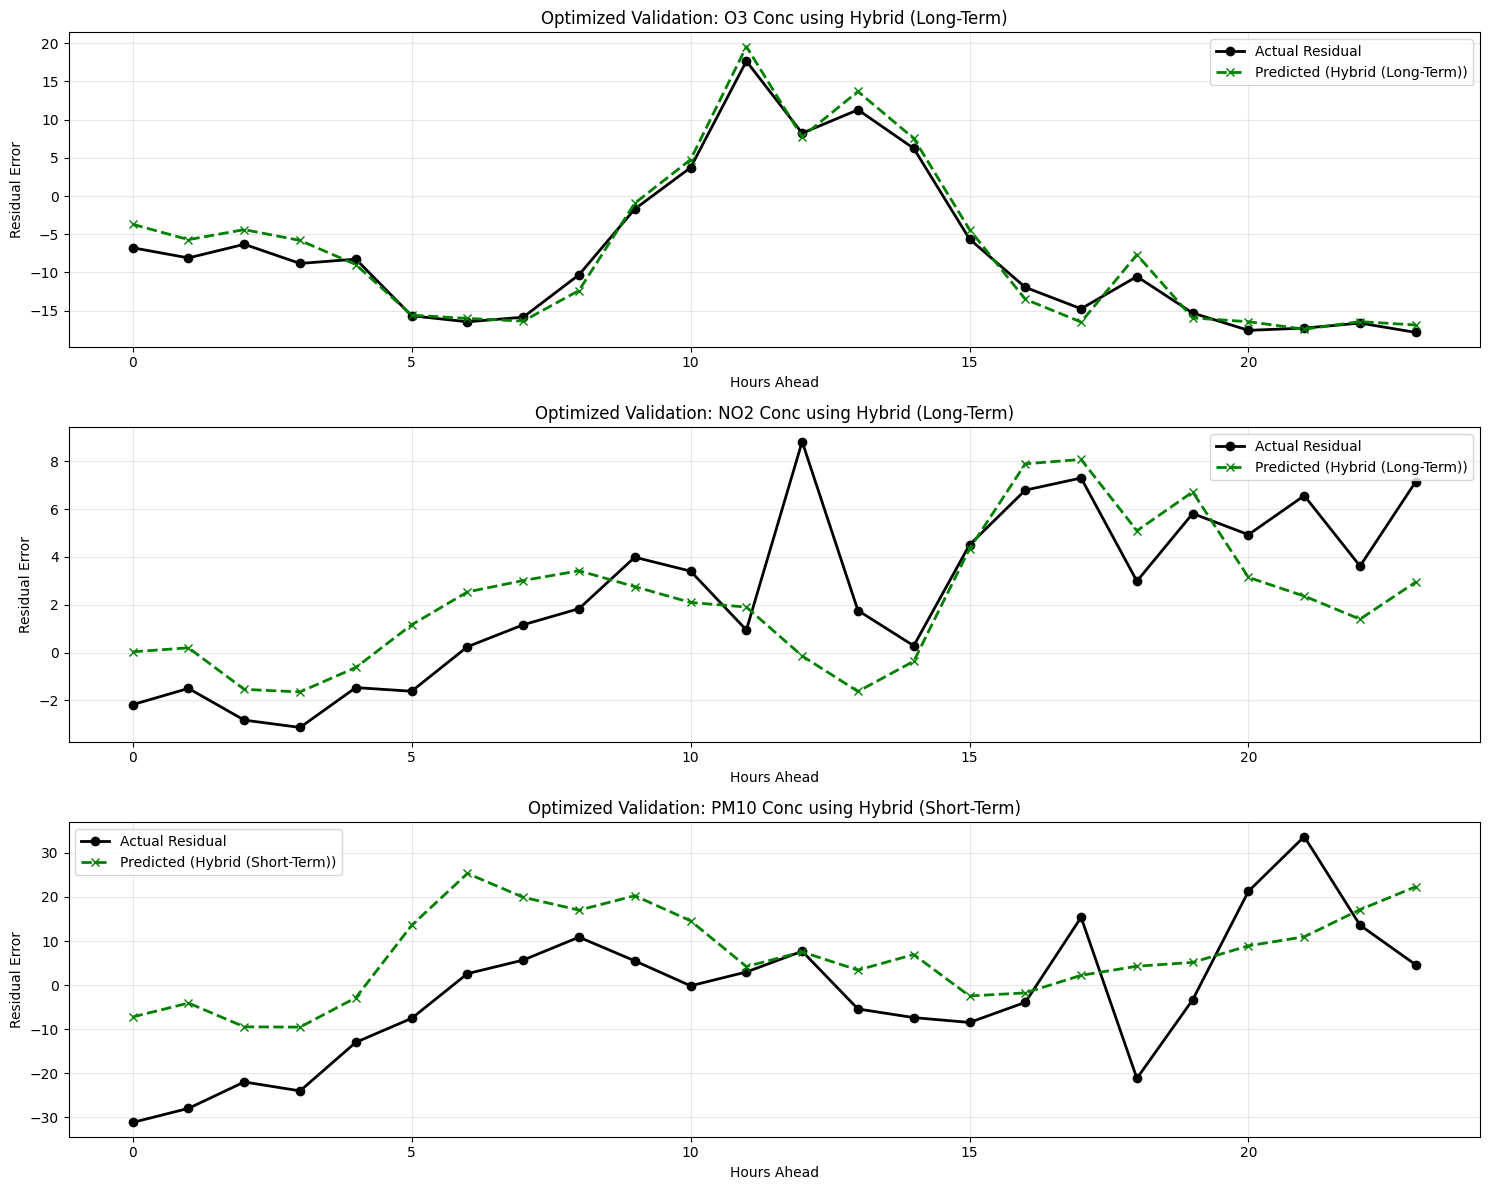

In [87]:
# Long-Term (NO2, O3, SO2)
map_long = tft.hparams.embedding_labels['pollutant_id']
# Invert: {'PM10': 0} -> {0: 'PM10'} so we can look up by name later if needed
name_to_id_long = tft.hparams.embedding_labels['pollutant_id']

# Short-Term (PM10, PM2.5)
name_to_id_short = tft_short.hparams.embedding_labels['pollutant_id']

pollutants_to_plot = ['O3 Conc', 'NO2 Conc', 'PM10 Conc']

plt.figure(figsize=(15, 12))

for i, poll_name in enumerate(pollutants_to_plot):
    plt.subplot(3, 1, i+1)
    
    # --- LOGIC TO PICK THE CORRECT MODEL ---
    # (Must match the teams you defined earlier)
    if poll_name in ['NO2 Conc', 'O3 Conc', 'SO2 Conc', 'NOx Conc', 'NO Conc']:
        target_pred = pred_long
        target_actuals = actuals_long
        target_x = x_long
        # Use the Long-Term dictionary
        current_map = name_to_id_long
        model_label = "Hybrid (Long-Term)"
    else:
        target_pred = pred_short
        target_actuals = actuals_short
        target_x = x_short
        # Use the Short-Term dictionary
        current_map = name_to_id_short
        model_label = "Hybrid (Short-Term)"
        
    # --- THE FIX IS HERE ---
    # Instead of decoder.transform([poll_name]), we just look it up
    if poll_name in current_map:
        g_id = current_map[poll_name]
    else:
        print(f"Skipping {poll_name} (Not found in model map)")
        continue
    
    # Find sample indices for this pollutant
    groups = target_x['groups'].cpu().numpy().flatten()
    indices = np.where(groups == g_id)[0]
    
    if len(indices) > 0:
        # Pick the first sample to plot
        sample_idx = indices[0]
        
        # Plot 24h Horizon
        plt.plot(target_actuals[sample_idx], label='Actual Residual', color='black', linewidth=2, marker='o')
        plt.plot(target_pred[sample_idx], label=f'Predicted ({model_label})', color='green', linewidth=2, linestyle='--', marker='x')
        
        plt.title(f"Optimized Validation: {poll_name} using {model_label}")
        plt.ylabel("Residual Error")
        plt.xlabel("Hours Ahead")
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        print(f"No validation samples found for {poll_name}")

plt.tight_layout()
plt.show()